# Transformers

## Definition
The Transformer is a deep learning architecture introduced in the paper *"Attention Is All You Need"* (Vaswani et al., 2017). It abandons recurrence entirely in favor of stacked Multi-Head Self-Attention and Feed-Forward layers, enabling full parallelization during training. The Transformer is the foundational architecture behind all modern large language models including BERT, GPT, T5, and beyond.

## Why It Is Needed
- **Parallelization:** Self-attention processes all tokens simultaneously, enabling orders-of-magnitude faster training than RNNs on GPUs/TPUs.
- **Long-Range Dependencies:** Every token directly attends to every other token — no information bottleneck from sequential processing.
- **Scalability:** Transformers scale efficiently with data and compute, leading to the era of Large Language Models (LLMs).

## Real-World Applications
- Machine translation (original use case)
- Large Language Models: ChatGPT, Gemini, Claude, LLaMA
- BERT-based models for search, NER, question answering
- T5/BART for summarization and text generation
- Vision Transformers (ViT) for image classification

## Important Points
- **Encoder Stack:** N identical layers, each with:
  1. Multi-Head Self-Attention
  2. Add & Layer Norm
  3. Position-wise Feed-Forward Network
  4. Add & Layer Norm
- **Decoder Stack:** N identical layers with an additional Cross-Attention sublayer between self-attention and FFN.
- **Multi-Head Attention (MHA):** Runs `h` parallel self-attention heads on different linear projections of Q, K, V — captures different types of relationships simultaneously.
  - `MultiHead(Q,K,V) = Concat(head₁, ..., headₕ) · Wₒ`
- **Positional Encoding:** Since Transformers have no recurrence, positional information is injected via sinusoidal or learned position embeddings added to input token embeddings.
  - `PE(pos, 2i) = sin(pos / 10000^(2i/d_model))`
  - `PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))`
- **Masked Self-Attention:** Used in the decoder to prevent attending to future positions during training (causal masking).
- **`d_model`:** The embedding dimension (default 512 in original paper). Number of heads `h = 8`, `dₖ = d_model / h = 64`.

## Visual Understanding
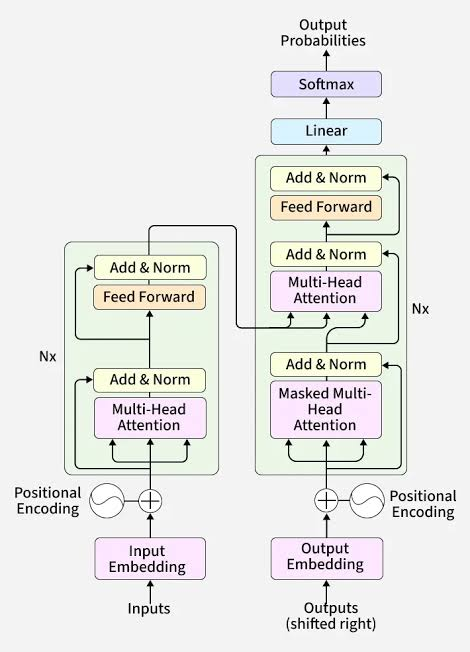

## Implementation
Practical implementation will be added here.

## Key Takeaways
- Transformers use Self-Attention exclusively — no recurrence, no convolutions.
- Multi-Head Attention runs parallel attention heads capturing diverse relationships.
- Positional Encoding is essential to inject token order since attention is permutation-invariant.
- The decoder uses Masked Self-Attention to prevent information leakage from future tokens.
- The Transformer is the foundation of the entire modern LLM ecosystem.

## Importing Libraries

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np

In [ ]:
class ScaledDotProductAttention(layers.Layer):
    def __init__(self, d_model):
        super(ScaledDotProductAttention, self).__init__()
        self.d_model = d_model

    def call(self, query, key, value, mask=None):
        # Compute attention scores
        matmul_qk = tf.matmul(query, key, transpose_b=True)

        # Scale by square root of d_model
        scaled_attention_logits = matmul_qk / tf.math.sqrt(tf.cast(self.d_model, tf.float32))

        if mask is not None:
            # Expand mask to the same shape as attention logits (batch_size, num_heads, seq_len, seq_len)
            mask = tf.expand_dims(mask, 1)  # Shape: (batch_size, 1, seq_len)
            mask = tf.expand_dims(mask, 2)  # Shape: (batch_size, 1, 1, seq_len)
            scaled_attention_logits += (mask * -1e9)  # Apply mask

        # Apply softmax to get attention weights
        attention_weights = tf.nn.softmax(scaled_attention_logits, axis=-1)

        # Multiply by value to get the output
        output = tf.matmul(attention_weights, value)

        return output, attention_weights

In [ ]:
class MultiHeadAttention(layers.Layer):
    def __init__(self, num_heads, d_model):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model

        assert d_model % self.num_heads == 0  # d_model should be divisible by num_heads

        self.depth = d_model // self.num_heads

        self.query_dense = layers.Dense(d_model)
        self.key_dense = layers.Dense(d_model)
        self.value_dense = layers.Dense(d_model)

        self.attention = ScaledDotProductAttention(d_model)

        self.dense_output = layers.Dense(d_model)

    def call(self, query, key, value, mask=None):
        batch_size = tf.shape(query)[0]

        # Linear transformations for queries, keys, and values
        query = self.query_dense(query)
        key = self.key_dense(key)
        value = self.value_dense(value)

        # Split into multiple heads
        query = self.split_into_heads(query, batch_size)
        key = self.split_into_heads(key, batch_size)
        value = self.split_into_heads(value, batch_size)

        # Apply attention
        attention_output, attention_weights = self.attention(query, key, value, mask)

        # Concatenate heads and apply final dense layer
        attention_output = self.combine_heads(attention_output, batch_size)
        output = self.dense_output(attention_output)

        return output, attention_weights

    def split_into_heads(self, x, batch_size):
        # Split the last dimension into (num_heads, depth)
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.depth))
        # Transpose to (batch_size, num_heads, seq_len, depth)
        return tf.transpose(x, perm=[0, 2, 1, 3])

    def combine_heads(self, x, batch_size):
        # Transpose to (batch_size, seq_len, num_heads, depth)
        x = tf.transpose(x, perm=[0, 2, 1, 3])
        # Concatenate the heads into the last dimension
        return tf.reshape(x, (batch_size, -1, self.d_model))

In [ ]:
class FeedForwardNetwork(layers.Layer):
    def __init__(self, d_model, d_ff):
        super(FeedForwardNetwork, self).__init__()
        self.dense1 = layers.Dense(d_ff, activation='relu')
        self.dense2 = layers.Dense(d_model)

    def call(self, x):
        x = self.dense1(x)
        return self.dense2(x)

In [ ]:
class EncoderLayer(layers.Layer):
    def __init__(self, num_heads, d_model, d_ff):
        super(EncoderLayer, self).__init__()
        self.multi_head_attention = MultiHeadAttention(num_heads, d_model)
        self.feed_forward = FeedForwardNetwork(d_model, d_ff)
        self.layer_norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layer_norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(0.1)
        self.dropout2 = layers.Dropout(0.1)

    def call(self, x, mask=None):
        # Multi-head attention
        attn_output, _ = self.multi_head_attention(x, x, x, mask)
        attn_output = self.dropout1(attn_output)
        out1 = self.layer_norm1(x + attn_output)

        # Feedforward network
        ff_output = self.feed_forward(out1)
        ff_output = self.dropout2(ff_output)
        return self.layer_norm2(out1 + ff_output)

In [ ]:
class DecoderLayer(layers.Layer):
    def __init__(self, num_heads, d_model, d_ff):
        super(DecoderLayer, self).__init__()
        self.multi_head_attention1 = MultiHeadAttention(num_heads, d_model)
        self.multi_head_attention2 = MultiHeadAttention(num_heads, d_model)
        self.feed_forward = FeedForwardNetwork(d_model, d_ff)
        self.layer_norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layer_norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.layer_norm3 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(0.1)
        self.dropout2 = layers.Dropout(0.1)
        self.dropout3 = layers.Dropout(0.1)

    def call(self, x, enc_output, look_ahead_mask, padding_mask):
        # Multi-head attention (self-attention)
        attn1, _ = self.multi_head_attention1(x, x, x, look_ahead_mask)
        attn1 = self.dropout1(attn1)
        out1 = self.layer_norm1(attn1 + x)

        # Multi-head attention (encoder-decoder attention)
        attn2, _ = self.multi_head_attention2(out1, enc_output, enc_output, padding_mask)
        attn2 = self.dropout2(attn2)
        out2 = self.layer_norm2(attn2 + out1)

        # Feedforward network
        ff_output = self.feed_forward(out2)
        ff_output = self.dropout3(ff_output)
        return self.layer_norm3(ff_output + out2)

In [ ]:
class Transformer(tf.keras.Model):
    def __init__(self, num_heads, d_model, num_layers, d_ff, vocab_size, max_len):
        super(Transformer, self).__init__()
        self.d_model = d_model
        self.num_layers = num_layers

        self.embedding = layers.Embedding(vocab_size, d_model)
        self.positional_encoding = self.get_positional_encoding(max_len, d_model)

        self.encoders = [EncoderLayer(num_heads, d_model, d_ff) for _ in range(num_layers)]
        self.decoders = [DecoderLayer(num_heads, d_model, d_ff) for _ in range(num_layers)]

        self.final_dense = layers.Dense(vocab_size)

    def get_positional_encoding(self, max_len, d_model):
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angles = pos / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        pos_encoding = np.concatenate([np.sin(angles[:, 0::2]), np.cos(angles[:, 1::2])], axis=-1)
        return tf.cast(pos_encoding, dtype=tf.float32)

    def call(self, x, enc_output, look_ahead_mask=None, padding_mask=None):
        x = self.embedding(x) + self.positional_encoding[:tf.shape(x)[1], :]
        for i in range(self.num_layers):
            x = self.encoders[i](x, padding_mask)

        for i in range(self.num_layers):
            x = self.decoders[i](x, enc_output, look_ahead_mask, padding_mask)

        return self.final_dense(x)

## NLP tasks using Transformers

In [ ]:
# Use a pre-trained transformer model (e.g., BERT) for sentiment analysis
from transformers import pipeline
classifier = pipeline("sentiment-analysis")
result = classifier("I love this product!")
print(result)


No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Device set to use cpu


[{'label': 'POSITIVE', 'score': 0.9998855590820312}]


In [ ]:
from transformers import pipeline
ner = pipeline("ner")
result = ner("Apple is looking at buying U.K. startup for $1 billion")
print(result)


No model was supplied, defaulted to dbmdz/bert-large-cased-finetuned-conll03-english and revision 4c53496 (https://huggingface.co/dbmdz/bert-large-cased-finetuned-conll03-english).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/998 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

Some weights of the model checkpoint at dbmdz/bert-large-cased-finetuned-conll03-english were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


tokenizer_config.json:   0%|          | 0.00/60.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

Device set to use cpu


[{'entity': 'I-ORG', 'score': np.float32(0.9990183), 'index': 1, 'word': 'Apple', 'start': 0, 'end': 5}, {'entity': 'I-LOC', 'score': np.float32(0.9996722), 'index': 6, 'word': 'U', 'start': 27, 'end': 28}, {'entity': 'I-LOC', 'score': np.float32(0.9979365), 'index': 8, 'word': 'K', 'start': 29, 'end': 30}]


In [ ]:
from transformers import pipeline
translator = pipeline("translation_en_to_fr")
result = translator("Hello, how are you?")
print(result)


No model was supplied, defaulted to google-t5/t5-base and revision a9723ea (https://huggingface.co/google-t5/t5-base).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/892M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

Device set to use cpu


[{'translation_text': 'Bonjour, comment êtes-vous?'}]


In [ ]:
from transformers import MarianMTModel, MarianTokenizer

model_name = "Helsinki-NLP/opus-mt-en-hi"
tokenizer = MarianTokenizer.from_pretrained(model_name)
model = MarianMTModel.from_pretrained(model_name)

translator = pipeline("translation", model=model, tokenizer=tokenizer)
translator("Good morning! Have a nice day.")

In [ ]:
from transformers import pipeline
generator = pipeline("text-generation")
result = generator("Once upon a time, in a land far away")
print(result)


No model was supplied, defaulted to openai-community/gpt2 and revision 607a30d (https://huggingface.co/openai-community/gpt2).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

...

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Device set to use cpu
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


[{'generated_text': "Once upon a time, in a land far away, and without any warning, and with no danger of becoming an enemy to the prince, that king, king and king's people, had assembled on a hill to fight the forces of his foes."}]


In [ ]:
from transformers import pipeline
qa = pipeline("question-answering")
result = qa(context="The capital of France is Paris.", question="What is the capital of France?")
print(result)


No model was supplied, defaulted to distilbert/distilbert-base-cased-distilled-squad and revision 564e9b5 (https://huggingface.co/distilbert/distilbert-base-cased-distilled-squad).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/473 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/261M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/436k [00:00<?, ?B/s]

Device set to use cpu


{'score': 0.9863281846046448, 'start': 25, 'end': 30, 'answer': 'Paris'}


In [ ]:
from transformers import pipeline
summarizer = pipeline("summarization")
result = summarizer("Long text here...", max_length=50, min_length=25)
print(result)


No model was supplied, defaulted to sshleifer/distilbart-cnn-12-6 and revision a4f8f3e (https://huggingface.co/sshleifer/distilbart-cnn-12-6).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/1.80k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

Device set to use cpu
Your max_length is set to 50, but your input_length is only 6. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=3)


[{'summary_text': ' Long text here: "Long text here... Long Text here" Long text is a picture of a scene from a scene in a novel . Long text .'}]


In [ ]:
from transformers import pipeline
completer = pipeline("text-generation")
result = completer("The sun rises in the")
print(result)


No model was supplied, defaulted to openai-community/gpt2 and revision 607a30d (https://huggingface.co/openai-community/gpt2).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use cpu
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


[{'generated_text': 'The sun rises in the morning and the sun turns to the sky again. But the sun has not yet risen, and when it has risen, the sun will be shining in the morning. (L. John 4:12,14 NIV)'}]
